In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
africa = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-01-13/africa.csv"
)
africa.tail(2)

,language,family,native_speakers,country
794,Zhoa,Niger–Congo,2000,Cameroon
795,Zulu,Niger–Congo,12000000,South Africa


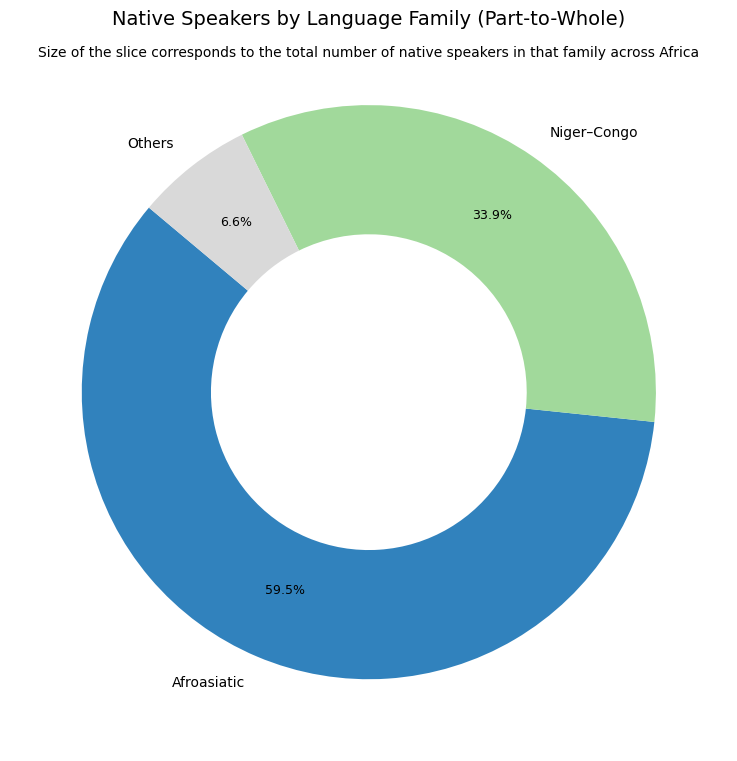

In [9]:
# Aggregate
df = (
    africa.groupby("family", as_index=False)["native_speakers"]
    .sum()
    .sort_values(by="native_speakers", ascending=False)
)

# Combine small categories into "Others" (threshold-based)
threshold = 0.03  # families <3% grouped into Others
total = df["native_speakers"].sum()
df["share"] = df["native_speakers"] / total

major = df[df["share"] >= threshold]
minor = df[df["share"] < threshold]

others = pd.DataFrame({
    "family": ["Others"],
    "native_speakers": [minor["native_speakers"].sum()]
})

df_final = pd.concat([major[["family", "native_speakers"]], others], ignore_index=True)

# Sort again
df_final = df_final.sort_values(by="native_speakers", ascending=False)

# Color palette (clean + modern)
colors = plt.cm.tab20c(np.linspace(0, 1, len(df_final)))

# Plot (donut chart)
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    df_final["native_speakers"],
    labels=df_final["family"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.45),
    pctdistance=0.75,
    labeldistance=1.1
)

# Improve readability
for t in texts:
    t.set_fontsize(10)

for at in autotexts:
    at.set_fontsize(9)

ax.set_title("Native Speakers by Language Family (Part-to-Whole)", fontsize=14)
plt.suptitle(
    "Size of the slice corresponds to the total number of native speakers in that family across Africa",
    fontsize=10,
    y=0.9
)
plt.tight_layout()
plt.show()